# UAS Sains Data - Car Price Prediction
Nama: Ginanjar Aditiya Prianata

NPM: 237006084

Notebook ini menyajikan proyek akhir mata kuliah Sains Data untuk memprediksi harga mobil menggunakan dataset `Car_sales.xls`. Alur kerja mengikuti kerangka CRISP-DM agar proses analisis terstruktur, reproducible, dan dapat dipertanggungjawabkan secara akademik.

## Business Understanding

Permasalahan bisnis pada studi ini adalah bagaimana perusahaan otomotif dapat memahami faktor-faktor spesifikasi kendaraan yang berpengaruh terhadap harga jual mobil. Prediksi harga yang akurat dapat membantu proses penetapan harga, evaluasi posisi produk di pasar, dan penyusunan strategi portofolio kendaraan.

Target prediksi pada notebook ini akan divalidasi langsung dari dataset, kemudian dimodelkan menggunakan `LinearRegression` sesuai instruksi proyek. Seluruh tahapan berikut dibangun berdasarkan hasil inspeksi data asli tanpa mengasumsikan struktur kolom di awal.

## Import Library

Tahap ini menyiapkan seluruh library yang dibutuhkan untuk membaca data, melakukan eksplorasi, membangun pipeline preprocessing, melatih model `LinearRegression`, dan mengevaluasi hasil prediksi. `random_state=42` digunakan untuk menjaga konsistensi pembagian data.

In [46]:
from pathlib import Path
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from google.colab import drive
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RANDOM_STATE = 42

## Setup Environment dan Dataset Path

Cell ini mendeteksi environment (Google Colab atau lokal) dan mencari file dataset dari tiga lokasi dengan prioritas:
1. **Google Drive**: `/MyDrive/dataset/Car_sales.xls` (folder dataset di Google Drive)
2. **Colab direct upload**: `/content/Car_sales.xls`
3. **Lokal**: `../dataset/Car_sales.xls`

Jika menjalankan di Google Colab untuk pertama kali, cell ini akan melakukan mounting otomatis ke Google Drive. File harus disimpan di subfolder `dataset` agar konsisten dengan struktur lokal.

In [47]:
# Deteksi environment dan setup path dataset
dataset_filename = 'Car_sales.xls'
DATASET_PATH = None

# Priority 1: Google Drive - subfolder dataset
if IS_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
        # Cek di /MyDrive/dataset/
        drive_path = Path('/content/drive/MyDrive/dataset') / dataset_filename
        if drive_path.exists():
            DATASET_PATH = drive_path
            print(f'✓ Dataset ditemukan di Google Drive: {DATASET_PATH}')
        else:
            # Buat folder dataset jika belum ada
            dataset_folder = Path('/content/drive/MyDrive/dataset')
            dataset_folder.mkdir(parents=True, exist_ok=True)
            print(f'ℹ Folder /MyDrive/dataset/ telah disiapkan. Silakan upload Car_sales.xls ke sana.')
    except Exception as e:
        print(f'! Google Drive mount gagal: {e}')

# Priority 2: Colab /content (direct upload)
if DATASET_PATH is None and IS_COLAB:
    colab_path = Path('/content') / dataset_filename
    if colab_path.exists():
        DATASET_PATH = colab_path
        print(f'✓ Dataset ditemukan di Colab /content: {DATASET_PATH}')

# Priority 3: Local relative path
if DATASET_PATH is None:
    local_path = Path('../dataset') / dataset_filename
    if local_path.exists():
        DATASET_PATH = local_path
        print(f'✓ Dataset ditemukan di path lokal: {DATASET_PATH}')

# Jika masih tidak ditemukan, gunakan default dan biarkan error jelas
if DATASET_PATH is None:
    if IS_COLAB:
        DATASET_PATH = Path('/content/drive/MyDrive/dataset') / dataset_filename
        print(f'⚠ File belum ditemukan di /MyDrive/dataset/')
        print(f'  Silakan upload Car_sales.xls ke Google Drive folder: /MyDrive/dataset/')
    else:
        DATASET_PATH = Path('../dataset') / dataset_filename
        print(f'⚠ File belum ditemukan di path: {DATASET_PATH}')

print(f'Menggunakan dataset path: {DATASET_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset ditemukan di Google Drive: /content/drive/MyDrive/dataset/Car_sales.xls
Menggunakan dataset path: /content/drive/MyDrive/dataset/Car_sales.xls


## Load Dataset

Sesuai spesifikasi file, pembacaan data dimulai dengan `pd.read_excel()`. Notebook ini dirancang untuk berjalan di **tiga environment** dengan dukungan otomatis:

**Di Google Colab:**
- Prioritas 1: Google Drive `/MyDrive/dataset/Car_sales.xls` (upload file ke subfolder `dataset`)
- Prioritas 2: Folder `/content/` (direct upload ke Colab jika folder dataset tidak ada)

**Di lokal:**
- Gunakan path relatif `../dataset/Car_sales.xls`

Fallback `pd.read_csv()` juga disediakan jika format file tidak sesuai harapan. Dengan pendekatan ini, notebook tetap patuh terhadap instruksi proyek sekaligus aman dijalankan dari awal sampai akhir di berbagai environment dengan struktur folder yang konsisten.

In [48]:
try:
    df = pd.read_excel(DATASET_PATH)
    load_method = 'pd.read_excel'
    print(f'✓ File berhasil dibaca dengan pd.read_excel')
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"❌ File tidak ditemukan di {DATASET_PATH}\n\n"
        f"Solusi:\n"
        f"- Di Google Colab: Upload Car_sales.xls ke folder /MyDrive/dataset/ (buat subfolder 'dataset' jika belum ada)\n"
        f"- Atau: Upload langsung ke /content/ folder Colab\n"
        f"- Jika lokal: Pastikan file ada di folder ../dataset/"
    ) from e
except Exception as exc:
    try:
        df = pd.read_csv(DATASET_PATH)
        load_method = f'pd.read_csv (fallback)'
        print(f'⚠ File dibaca dengan pd.read_csv (fallback dari {exc.__class__.__name__})')
    except Exception as csv_exc:
        raise FileNotFoundError(
            f"❌ Gagal membaca file dengan kedua metode\n"
            f"Path: {DATASET_PATH}\n"
            f"Error read_excel: {exc}\n"
            f"Error read_csv: {csv_exc}"
        ) from csv_exc

print(f'Metode pembacaan data: {load_method}')
display(df.head())

⚠ File dibaca dengan pd.read_csv (fallback dari ValueError)
Metode pembacaan data: pd.read_csv (fallback)


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2/2/2012,58.280
1,Acura,TL,39.384,19.875,Passenger,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,6/3/2011,91.371
2,Acura,CL,14.114,18.225,Passenger,NaN,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,3/10/2011,91.390
4,Audi,A4,20.397,22.255,Passenger,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,10/8/2011,62.778


## Inspeksi Struktur Dataset

Tahap ini bertujuan untuk memahami struktur data asli sebelum melakukan preprocessing apa pun. Inspeksi dilakukan menggunakan `head()`, `info()`, `describe()`, `columns`, dan `shape` agar pemilihan fitur dan strategi analisis benar-benar berbasis dataset.

In [49]:
print('Shape dataset:', df.shape)
print('\nDaftar kolom:')
print(df.columns.tolist())
print('\nInformasi dataset:')
df.info()
print('\nLima baris pertama:')
display(df.head())
print('\nStatistik deskriptif:')
display(df.describe(include='all').transpose())

Shape dataset: (157, 16)

Daftar kolom:
['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value', 'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2/2/2012,58.280
1,Acura,TL,39.384,19.875,Passenger,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,6/3/2011,91.371
2,Acura,CL,14.114,18.225,Passenger,NaN,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,3/10/2011,91.390
4,Audi,A4,20.397,22.255,Passenger,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,10/8/2011,62.778



Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Manufacturer,157,30,Ford,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,157,156,Neon,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_in_thousands,157.000,NaN,NaN,NaN,52.998,68.029,0.110,14.114,29.450,67.956,540.561
__year_resale_value,121.000,NaN,NaN,NaN,18.073,11.453,5.160,11.260,14.180,19.875,67.550
Vehicle_type,157,2,Passenger,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price_in_thousands,155.000,NaN,NaN,NaN,27.391,14.352,9.235,18.017,22.799,31.947,85.500
Engine_size,156.000,NaN,NaN,NaN,3.061,1.045,1.000,2.300,3.000,3.575,8.000
Horsepower,156.000,NaN,NaN,NaN,185.949,56.700,55.000,149.500,177.500,215.000,450.000
Wheelbase,156.000,NaN,NaN,NaN,107.487,7.641,92.600,103.000,107.000,112.200,138.700
Width,156.000,NaN,NaN,NaN,71.150,3.452,62.600,68.400,70.550,73.425,79.900


## Analisis Missing Value, Duplikasi, dan Tipe Data

Sebelum membersihkan data, perlu diidentifikasi jumlah nilai hilang pada setiap kolom, keberadaan data duplikat, serta tipe data awal yang terbaca oleh pandas. Informasi ini akan menjadi dasar untuk memilih strategi imputasi dan validasi tipe data pada tahap persiapan data.

In [50]:
missing_summary = df.isnull().sum().sort_values(ascending=False).to_frame('missing_count')
missing_summary['missing_percentage'] = (missing_summary['missing_count'] / len(df) * 100).round(2)

display(missing_summary)
print('Jumlah baris duplikat:', df.duplicated().sum())
display(df.dtypes.to_frame('dtype'))

,missing_count,missing_percentage
__year_resale_value,36,22.930
Fuel_efficiency,3,1.910
Curb_weight,2,1.270
Price_in_thousands,2,1.270
Power_perf_factor,2,1.270
Wheelbase,1,0.640
Engine_size,1,0.640
Horsepower,1,0.640
Length,1,0.640
Width,1,0.640


Jumlah baris duplikat: 0


,dtype
Manufacturer,object
Model,object
Sales_in_thousands,float64
__year_resale_value,float64
Vehicle_type,object
Price_in_thousands,float64
Engine_size,float64
Horsepower,float64
Wheelbase,float64
Width,float64


## Standarisasi Tipe Data

Tahap ini menstandarkan kolom numerik dan tanggal berdasarkan hasil inspeksi dataset. Konversi dilakukan secara eksplisit agar fitur numerik benar-benar bertipe numerik dan kolom tanggal dapat dikenali dengan benar untuk analisis lanjutan. Langkah ini penting agar tidak ada `object dtype` yang tidak semestinya terbawa ke proses modeling.

In [51]:
df_prep = df.copy()

numeric_candidate_cols = [
    'Sales_in_thousands',
    '__year_resale_value',
    'Price_in_thousands',
    'Engine_size',
    'Horsepower',
    'Wheelbase',
    'Width',
    'Length',
    'Curb_weight',
    'Fuel_capacity',
    'Fuel_efficiency',
    'Power_perf_factor'
]

for col in numeric_candidate_cols:
    if col in df_prep.columns:
        df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

if 'Latest_Launch' in df_prep.columns:
    df_prep['Latest_Launch'] = pd.to_datetime(df_prep['Latest_Launch'], errors='coerce')

print('Tipe data setelah standarisasi:')
display(df_prep.dtypes.to_frame('dtype'))

Tipe data setelah standarisasi:


,dtype
Manufacturer,object
Model,object
Sales_in_thousands,float64
__year_resale_value,float64
Vehicle_type,object
Price_in_thousands,float64
Engine_size,float64
Horsepower,float64
Wheelbase,float64
Width,float64


## Strategi Penanganan Missing Value

Karena target prediksi harus valid, baris yang tidak memiliki nilai target tidak dapat digunakan untuk pelatihan model. Untuk fitur prediktor, imputasi tidak dilakukan secara manual pada seluruh data mentah, melainkan didelegasikan ke pipeline modeling agar proses training tetap rapi dan menghindari data leakage.

Pada tahap ini, notebook hanya memisahkan data yang memiliki target valid serta menampilkan baris yang kehilangan target agar alasan pembersihan data tetap transparan.

In [52]:
target_column = 'Price_in_thousands'

if target_column not in df_prep.columns:
    raise KeyError(f'Kolom target {target_column} tidak ditemukan di dataset.')

missing_target_rows = df_prep[df_prep[target_column].isna()][['Manufacturer', 'Model', target_column]]
print('Baris dengan target yang hilang:')
display(missing_target_rows)

df_model = df_prep.dropna(subset=[target_column]).copy()
print('Ukuran dataset setelah menghapus baris tanpa target:', df_model.shape)

Baris dengan target yang hilang:


,Manufacturer,Model,Price_in_thousands
2,Acura,CL,NaN
33,Chrysler,Town & Country,NaN


Ukuran dataset setelah menghapus baris tanpa target: (155, 16)


## Exploratory Data Analysis: Top 10 Best Selling Cars

Analisis pertama berfokus pada model kendaraan dengan penjualan tertinggi. Visualisasi ini membantu memahami produk mana yang paling dominan di pasar dan bagaimana posisi harga dari kendaraan yang paling banyak terjual.

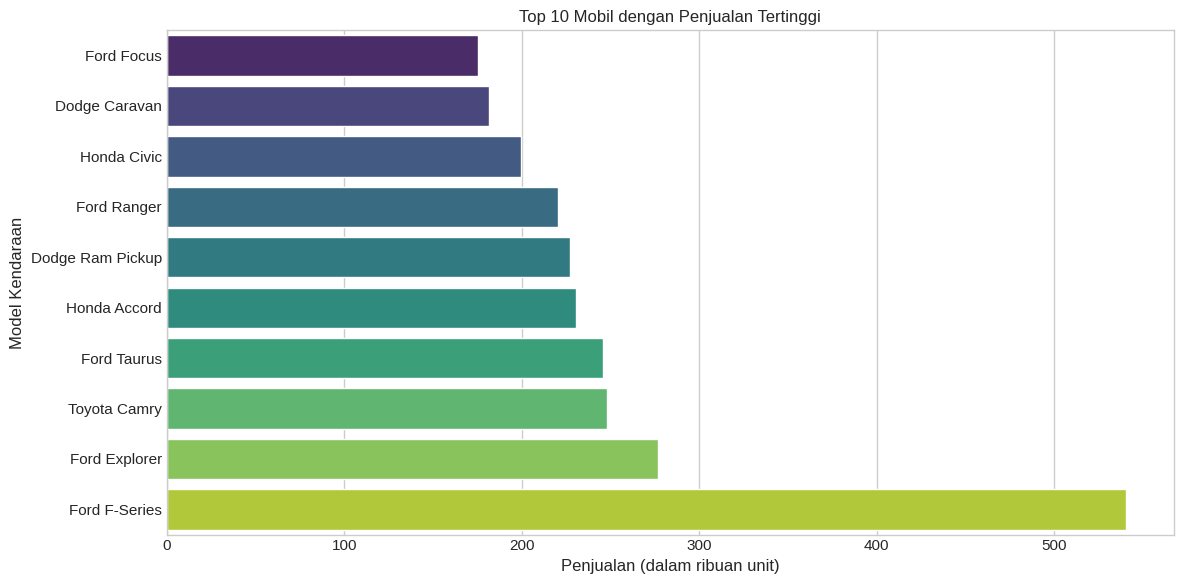

,Full_Model,Sales_in_thousands,Price_in_thousands
56,Ford F-Series,540.561,26.935
52,Ford Explorer,276.747,31.930
137,Toyota Camry,247.994,17.518
49,Ford Taurus,245.815,17.885
58,Honda Accord,230.902,15.350
40,Dodge Ram Pickup,227.061,19.460
55,Ford Ranger,220.650,12.050
57,Honda Civic,199.685,12.885
45,Dodge Caravan,181.749,19.565
50,Ford Focus,175.670,12.315


In [53]:
top_10_sales = (
    df_model[['Manufacturer', 'Model', 'Sales_in_thousands', 'Price_in_thousands']]
    .sort_values('Sales_in_thousands', ascending=False)
    .head(10)
    .copy()
)
top_10_sales['Full_Model'] = top_10_sales['Manufacturer'] + ' ' + top_10_sales['Model']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_sales.sort_values('Sales_in_thousands'),
    x='Sales_in_thousands',
    y='Full_Model',
    palette='viridis'
)
plt.title('Top 10 Mobil dengan Penjualan Tertinggi')
plt.xlabel('Penjualan (dalam ribuan unit)')
plt.ylabel('Model Kendaraan')
plt.tight_layout()
plt.show()

display(top_10_sales[['Full_Model', 'Sales_in_thousands', 'Price_in_thousands']])

Interpretasi awal dari dataset menunjukkan bahwa model-model seperti Ford F-Series, Ford Explorer, dan Toyota Camry berada pada kelompok penjualan tertinggi. Pola ini mengindikasikan bahwa volume penjualan besar tidak selalu identik dengan harga tertinggi, sehingga analisis hubungan antara harga dan permintaan pasar perlu dilakukan lebih lanjut.

## Exploratory Data Analysis: Hubungan Harga dan Tingkat Penjualan

Visualisasi berikut membandingkan harga kendaraan dengan tingkat penjualannya. Tujuannya adalah untuk melihat apakah kendaraan dengan harga lebih tinggi cenderung memiliki penjualan lebih rendah, atau apakah terdapat segmen tertentu yang tetap mampu mencatat penjualan kuat meskipun harga relatif tinggi.

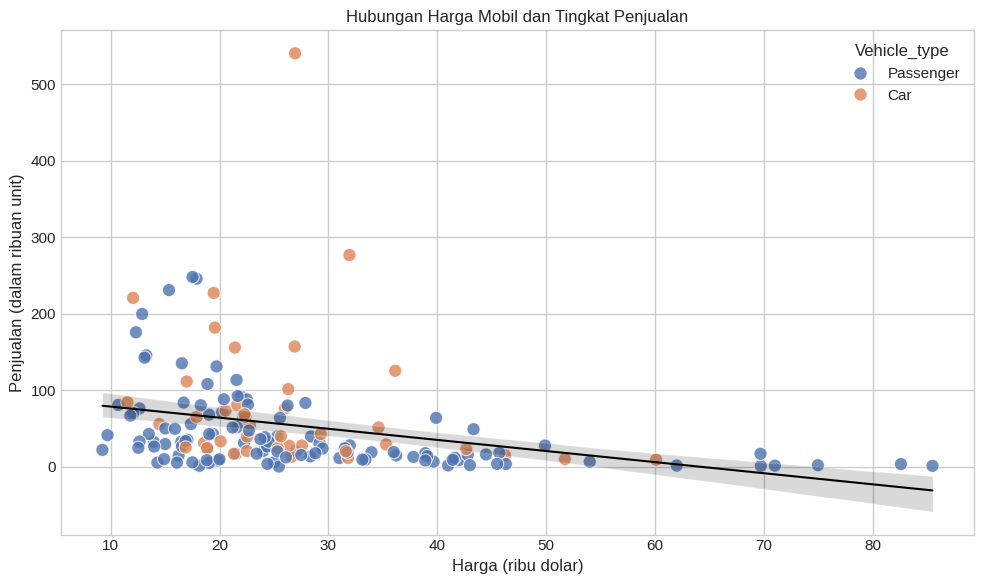

Korelasi harga terhadap penjualan: -0.305


In [54]:
price_sales_df = df_model[['Price_in_thousands', 'Sales_in_thousands', 'Vehicle_type']].dropna().copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=price_sales_df,
    x='Price_in_thousands',
    y='Sales_in_thousands',
    hue='Vehicle_type',
    s=90,
    alpha=0.8
)
sns.regplot(
    data=price_sales_df,
    x='Price_in_thousands',
    y='Sales_in_thousands',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.5}
)
plt.title('Hubungan Harga Mobil dan Tingkat Penjualan')
plt.xlabel('Harga (ribu dolar)')
plt.ylabel('Penjualan (dalam ribuan unit)')
plt.tight_layout()
plt.show()

print('Korelasi harga terhadap penjualan:', price_sales_df['Price_in_thousands'].corr(price_sales_df['Sales_in_thousands']).round(3))

Hubungan harga dan penjualan pada dataset ini cenderung negatif moderat. Artinya, kendaraan dengan harga lebih tinggi relatif memiliki volume penjualan yang lebih kecil, meskipun tetap terdapat beberapa pengecualian berdasarkan tipe kendaraan dan posisi produk di pasar.

## Exploratory Data Analysis: Analisis Variabel Spesifikasi Kendaraan

Sesuai instruksi proyek, analisis dilanjutkan pada beberapa fitur lain yang memang tersedia di dataset. Tiga variabel utama yang dianalisis di tahap ini adalah `Horsepower`, `Engine_size`, dan `Fuel_efficiency`, karena ketiganya relevan secara bisnis dan secara umum berhubungan dengan performa serta efisiensi kendaraan.

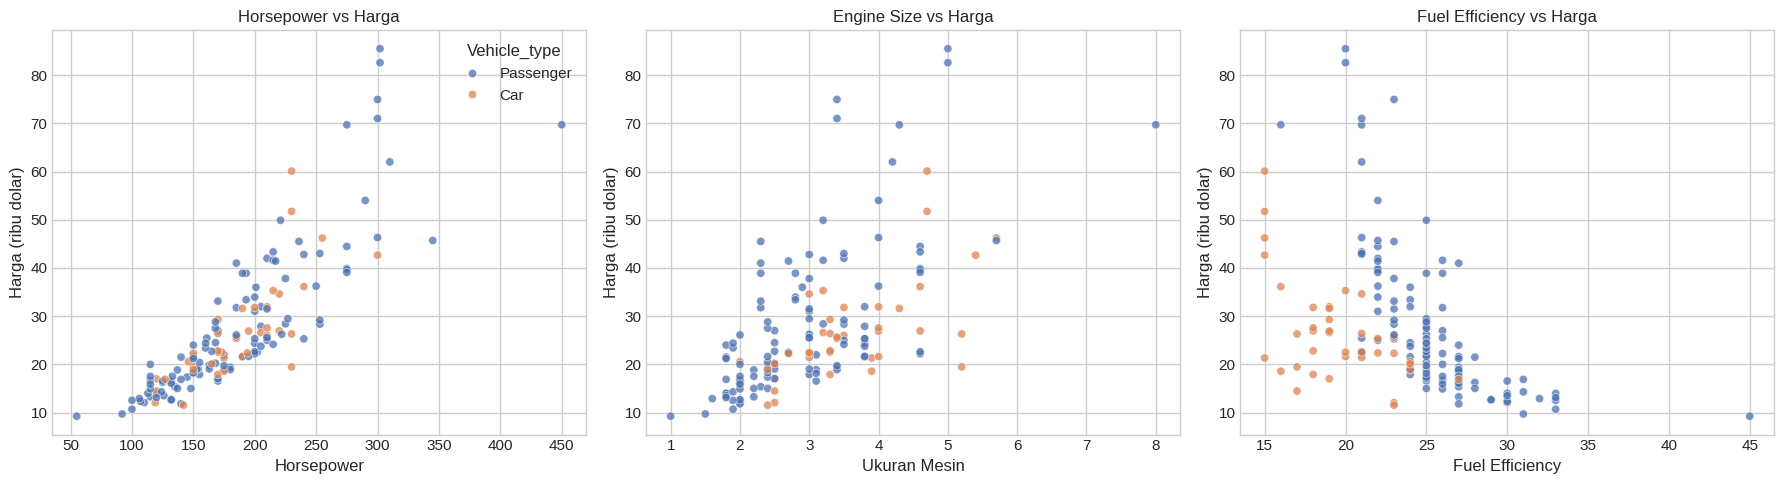

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df_model,
    x='Horsepower',
    y='Price_in_thousands',
    hue='Vehicle_type',
    alpha=0.75,
    ax=axes[0]
)
axes[0].set_title('Horsepower vs Harga')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Harga (ribu dolar)')

sns.scatterplot(
    data=df_model,
    x='Engine_size',
    y='Price_in_thousands',
    hue='Vehicle_type',
    alpha=0.75,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Engine Size vs Harga')
axes[1].set_xlabel('Ukuran Mesin')
axes[1].set_ylabel('Harga (ribu dolar)')

sns.scatterplot(
    data=df_model,
    x='Fuel_efficiency',
    y='Price_in_thousands',
    hue='Vehicle_type',
    alpha=0.75,
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Fuel Efficiency vs Harga')
axes[2].set_xlabel('Fuel Efficiency')
axes[2].set_ylabel('Harga (ribu dolar)')

plt.tight_layout()
plt.show()

Visualisasi menunjukkan kecenderungan bahwa harga meningkat seiring kenaikan `Horsepower` dan `Engine_size`. Sebaliknya, `Fuel_efficiency` cenderung bergerak berlawanan dengan harga, yang masuk akal karena mobil berperforma tinggi umumnya memiliki konsumsi bahan bakar yang lebih boros.

## Exploratory Data Analysis: Perbandingan Harga berdasarkan Tipe Kendaraan

Selain fitur numerik, tipe kendaraan juga penting untuk dibandingkan karena struktur harga antara mobil penumpang dan kendaraan utilitas dapat berbeda. Boxplot digunakan untuk melihat pusat distribusi, variasi, dan potensi outlier harga pada setiap kategori kendaraan.

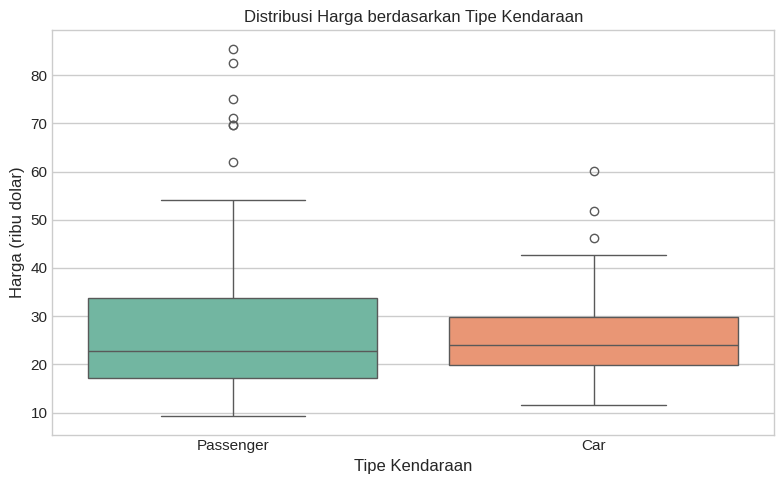

In [56]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_model, x='Vehicle_type', y='Price_in_thousands', palette='Set2')
plt.title('Distribusi Harga berdasarkan Tipe Kendaraan')
plt.xlabel('Tipe Kendaraan')
plt.ylabel('Harga (ribu dolar)')
plt.tight_layout()
plt.show()

Boxplot ini membantu melihat apakah perbedaan harga antar tipe kendaraan cukup mencolok. Jika sebaran harga antara kategori berbeda cukup jelas, maka `Vehicle_type` layak dipertimbangkan sebagai fitur kategorikal pada model prediksi.

## Correlation Analysis

Tahap ini menghitung korelasi antar fitur numerik untuk memahami hubungan linear dengan target dan untuk membantu feature selection. Heatmap digunakan agar pola hubungan antar variabel dapat dibaca dengan lebih mudah.

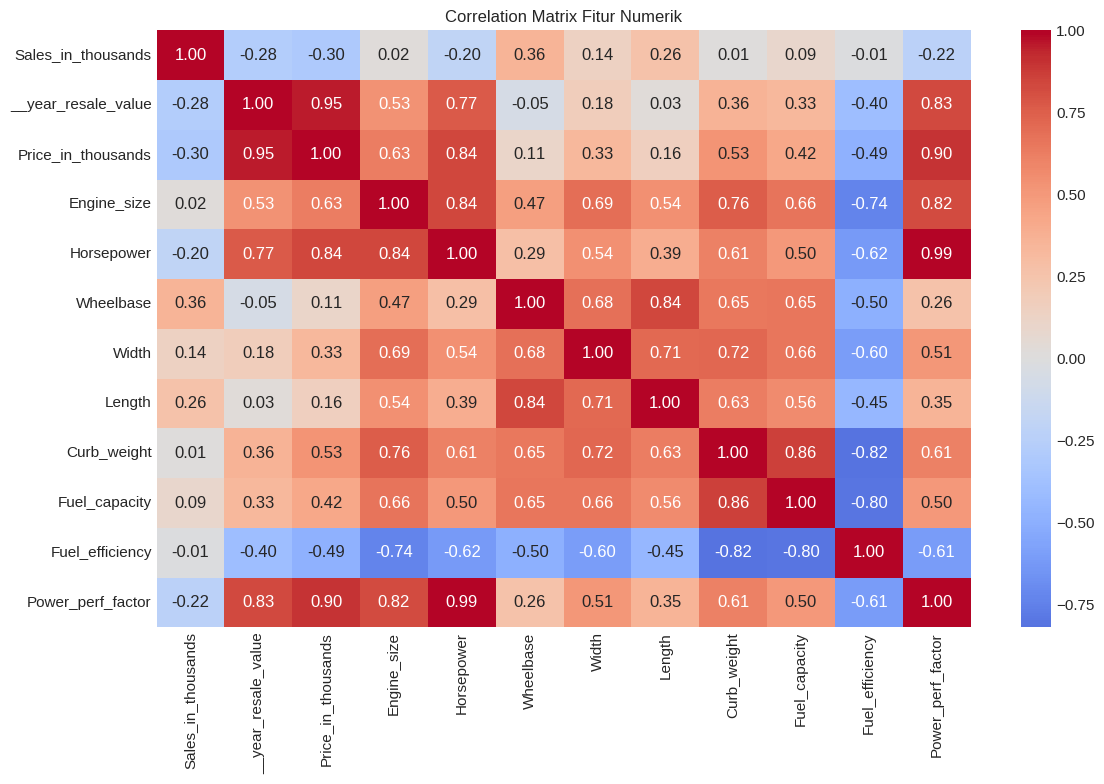

,correlation_to_price
Price_in_thousands,1.000
__year_resale_value,0.954
Power_perf_factor,0.898
Horsepower,0.840
Engine_size,0.627
Curb_weight,0.526
Fuel_capacity,0.423
Width,0.329
Length,0.157
Wheelbase,0.111


In [57]:
numeric_df = df_model.select_dtypes(include='number').copy()
correlation_matrix = numeric_df.corr(numeric_only=True)
price_correlation = correlation_matrix[target_column].sort_values(ascending=False).to_frame('correlation_to_price')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix Fitur Numerik')
plt.tight_layout()
plt.show()

display(price_correlation)

Hasil korelasi umumnya menunjukkan bahwa variabel performa dan dimensi kendaraan memiliki hubungan yang lebih kuat dengan harga dibandingkan variabel lain. Meskipun `__year_resale_value` dan `Power_perf_factor` dapat memiliki korelasi tinggi, keduanya tidak langsung dipakai pada model final karena pertimbangan interpretabilitas dan risiko informasi yang terlalu dekat dengan nilai harga aktual.

## Feature Selection

Pemilihan fitur dilakukan berdasarkan tiga pertimbangan utama: relevansi bisnis, ketersediaan data, dan hasil korelasi terhadap target. Fitur yang dipilih difokuskan pada karakteristik kendaraan yang lebih masuk akal digunakan untuk menjelaskan harga, yaitu merek, tipe kendaraan, ukuran mesin, performa mesin, dimensi fisik, bobot kendaraan, kapasitas bahan bakar, dan efisiensi bahan bakar.

Kolom `Sales_in_thousands` tidak digunakan sebagai fitur model karena lebih merepresentasikan respons pasar setelah produk dijual. Kolom `__year_resale_value` juga tidak digunakan agar prediksi harga tidak bergantung pada informasi nilai jual kembali.

In [58]:
selected_features = [
    'Manufacturer',
    'Vehicle_type',
    'Engine_size',
    'Horsepower',
    'Wheelbase',
    'Width',
    'Length',
    'Curb_weight',
    'Fuel_capacity',
    'Fuel_efficiency'
]

missing_features = [col for col in selected_features if col not in df_model.columns]
if missing_features:
    raise KeyError(f'Fitur berikut tidak ditemukan di dataset: {missing_features}')

X = df_model[selected_features].copy()
y = df_model[target_column].copy()

print('Fitur terpilih:')
print(selected_features)
print('\nUkuran matriks fitur:', X.shape)
print('Ukuran target:', y.shape)
display(X.head())

Fitur terpilih:
['Manufacturer', 'Vehicle_type', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']

Ukuran matriks fitur: (155, 10)
Ukuran target: (155,)


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,Acura,Passenger,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000
1,Acura,Passenger,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000
3,Acura,Passenger,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000
4,Audi,Passenger,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000
5,Audi,Passenger,2.800,200.000,108.700,76.100,192.000,3.561,18.500,22.000


## Train-Test Split dan Pipeline Preprocessing

Data kemudian dibagi menjadi data latih dan data uji dengan proporsi 80:20 menggunakan `random_state=42`. Untuk menjaga alur preprocessing tetap konsisten dan bebas data leakage, imputasi numerik menggunakan median, imputasi kategorikal menggunakan modus, dan encoding kategorikal dilakukan di dalam pipeline modeling.

In [59]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Ukuran X_train:', X_train.shape)
print('Ukuran X_test:', X_test.shape)
print('Ukuran y_train:', y_train.shape)
print('Ukuran y_test:', y_test.shape)

Ukuran X_train: (124, 10)
Ukuran X_test: (31, 10)
Ukuran y_train: (124,)
Ukuran y_test: (31,)


## Training Model Linear Regression

Tahap ini melatih model `LinearRegression` menggunakan data latih yang telah melewati pipeline preprocessing. Karena preprocessing dimasukkan ke dalam pipeline, transformasi yang diterapkan pada data latih dan data uji akan konsisten.

In [60]:
model.fit(X_train, y_train)
print('Model Linear Regression berhasil dilatih.')

Model Linear Regression berhasil dilatih.


## Evaluasi Model

Evaluasi dilakukan menggunakan dua metrik utama sesuai instruksi proyek, yaitu Root Mean Squared Error (RMSE) dan `R2 Score`. RMSE menunjukkan rata-rata besar kesalahan prediksi dalam satuan harga, sedangkan `R2 Score` menunjukkan proporsi variasi target yang dapat dijelaskan oleh model.

In [61]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

evaluation_summary = pd.DataFrame(
    {
        'Metric': ['RMSE', 'R2 Score'],
        'Value': [rmse, r2]
    }
)

display(evaluation_summary)

,Metric,Value
0,RMSE,6.692
1,R2 Score,0.792


RMSE yang lebih kecil menunjukkan kesalahan prediksi yang lebih rendah, sedangkan nilai `R2 Score` yang mendekati 1 menunjukkan kemampuan model yang semakin baik dalam menjelaskan variasi harga mobil. Interpretasi akhir harus dibaca berdasarkan angka evaluasi yang muncul setelah notebook dijalankan.

## Visualisasi Actual vs Predicted

Scatter plot antara nilai aktual dan nilai prediksi digunakan untuk melihat pola error model secara visual. Semakin dekat titik-titik terhadap garis diagonal, semakin baik kualitas prediksi model terhadap data uji.

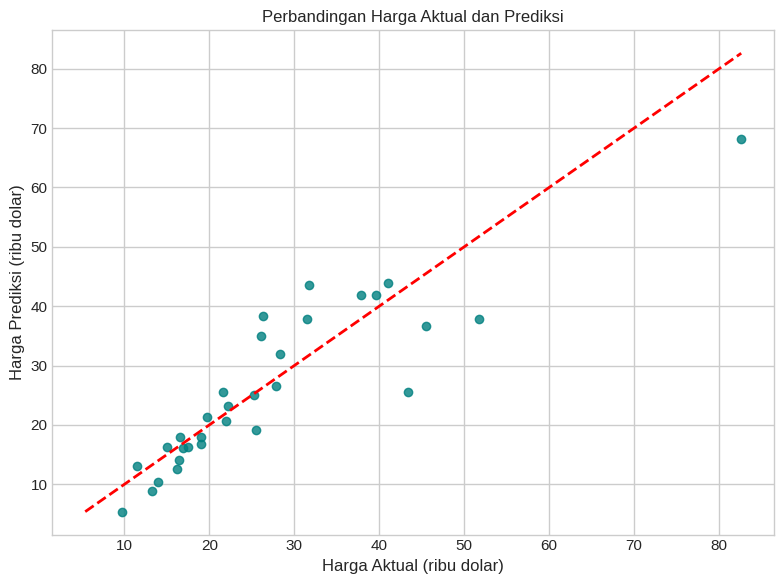

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.8, color='teal')
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], color='red', linestyle='--', linewidth=2)
plt.title('Perbandingan Harga Aktual dan Prediksi')
plt.xlabel('Harga Aktual (ribu dolar)')
plt.ylabel('Harga Prediksi (ribu dolar)')
plt.tight_layout()
plt.show()

## Prediction Pipeline untuk Data Baru

Tahap ini mencontohkan bagaimana model digunakan untuk melakukan prediksi pada satu observasi baru dengan struktur kolom yang identik dengan data training. Untuk menjaga konsistensi dan validitas format input, contoh data baru diambil dari satu baris data uji lalu dibentuk kembali menjadi `DataFrame` dengan urutan fitur yang sama.

In [63]:
original_idx = X_test.index[0]
new_data = pd.DataFrame([X_test.iloc[0].to_dict()])[selected_features]
actual_price_example = y_test.loc[original_idx]
predicted_price_example = model.predict(new_data)[0]

print('Contoh data baru untuk prediksi:')
display(new_data)

prediction_result = pd.DataFrame(
    {
        'Harga_Aktual': [actual_price_example],
        'Harga_Prediksi': [predicted_price_example],
        'Selisih_Absolut': [abs(actual_price_example - predicted_price_example)]
    }
)

display(prediction_result)

Contoh data baru untuk prediksi:


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,Mitsubishi,Passenger,3.000,161.000,97.200,72.400,180.300,3.131,19.800,21.000


,Harga_Aktual,Harga_Prediksi,Selisih_Absolut
0,25.450,19.074,6.376


## Interpretasi Hasil Prediksi

Hasil prediksi pada contoh observasi di atas menunjukkan bagaimana kombinasi merek, tipe kendaraan, performa mesin, dimensi, bobot, kapasitas bahan bakar, dan efisiensi bahan bakar digunakan model untuk memperkirakan harga mobil. Jika selisih antara harga aktual dan harga prediksi relatif kecil, maka model dapat dianggap cukup representatif untuk mendukung analisis harga awal.

Secara bisnis, insight utama dari notebook ini adalah bahwa atribut teknis kendaraan memiliki hubungan yang jelas dengan harga jual. Dengan demikian, perusahaan dapat menggunakan model ini sebagai alat bantu awal untuk memahami arah penetapan harga, meskipun keputusan final tetap perlu mempertimbangkan faktor pasar lain seperti strategi merek, kompetitor, dan kondisi permintaan.

## Prediksi Harga Mobil Berdasarkan Spesifikasi Custom

Tahap ini memungkinkan user untuk melakukan prediksi harga mobil dengan memasukkan spesifikasi kendaraan secara manual. Input dapat disesuaikan dengan karakteristik kendaraan yang ingin diprediksi harganya.

In [64]:
# Fungsi pembantu untuk mencari model terdekat
def find_nearest_models(input_dict, reference_df, selected_features, top_n=3):
    ref = reference_df.copy()
    manuf = input_dict.get('Manufacturer')
    if manuf in ref['Manufacturer'].values:
        ref = ref[ref['Manufacturer'] == manuf]
    
    num_features = [f for f in selected_features if f not in ['Manufacturer', 'Vehicle_type']]
    dist_sq = 0
    for feature in num_features:
        f_min = reference_df[feature].min()
        f_max = reference_df[feature].max()
        f_range = f_max - f_min if f_max != f_min else 1
        dist_sq += ((ref[feature] - input_dict[feature]) / f_range) ** 2
    
    ref['Similarity_Score'] = np.sqrt(dist_sq)
    return ref.sort_values('Similarity_Score').head(top_n)

# Prediksi harga mobil berdasarkan spesifikasi custom
custom_prediction_data = {
    'Manufacturer': 'Toyota',           # Merek kendaraan
    'Vehicle_type': 'Car',              # Tipe kendaraan
    'Engine_size': 2.5,                 # Ukuran mesin (liter)
    'Horsepower': 180,                  # Tenaga mesin (hp)
    'Wheelbase': 109,                   # Jarak antara roda (inch)
    'Width': 70,                        # Lebar kendaraan (inch)
    'Length': 184,                      # Panjang kendaraan (inch)
    'Curb_weight': 3.200,               # Bobot kendaraan (lbs/1000)
    'Fuel_capacity': 14.0,              # Kapasitas tangki (gallons)
    'Fuel_efficiency': 28.0             # Efisiensi bahan bakar (mpg)
}

# Buat DataFrame dari input user
custom_car = pd.DataFrame([custom_prediction_data])[selected_features]

print('='*60)
print('PREDIKSI HARGA MOBIL - INPUT SPESIFIKASI')
print('='*60)
print('\nSpesifikasi Kendaraan:')
display(custom_car)

# Lakukan prediksi
predicted_price = model.predict(custom_car)[0]
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
lower_bound = predicted_price - 1.96 * rmse_val
upper_bound = predicted_price + 1.96 * rmse_val

print('\n' + '='*60)
print('HASIL PREDIKSI HARGA')
print('='*60)

result_df = pd.DataFrame({
    'Metrik': ['Harga Prediksi', 'Interval Keyakinan (95%)', 'Batas Bawah', 'Batas Atas'],
    'Nilai (ribu dolar)': [
        f'${predicted_price:,.2f}',
        f'±${abs(upper_bound - predicted_price):,.2f}',
        f'${lower_bound:,.2f}',
        f'${upper_bound:,.2f}'
    ]
})
display(result_df)

# Cari model terdekat di dataset
nearest_models = find_nearest_models(custom_prediction_data, df_prep.dropna(subset=[target_column]), selected_features)

print('\n' + '='*60)
print(f'MODEL TERDEKAT DARI DATABASE ({custom_prediction_data["Manufacturer"]})')
print('='*60)
display(nearest_models[['Manufacturer', 'Model', 'Price_in_thousands', 'Similarity_Score']])

print('\n📊 Interpretasi:')
print(f'Harga prediksi: ${predicted_price:,.0f}k (Range: ${lower_bound:,.0f}k - ${upper_bound:,.0f}k)')
print(f'Spesifikasi ini paling mendekati model: {nearest_models.iloc[0]["Manufacturer"]} {nearest_models.iloc[0]["Model"]}')
print(f'dengan harga asli di database: ${nearest_models.iloc[0]["Price_in_thousands"]:,.2f}k')

PREDIKSI HARGA MOBIL - INPUT SPESIFIKASI

Spesifikasi Kendaraan:


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,Toyota,Car,2.500,180,109,70,184,3.200,14.000,28.000



HASIL PREDIKSI HARGA


,Metrik,Nilai (ribu dolar)
0,Harga Prediksi,$20.81
1,Interval Keyakinan (95%),±$13.12
2,Batas Bawah,$7.70
3,Batas Atas,$33.93



MODEL TERDEKAT DARI DATABASE (Toyota)


,Manufacturer,Model,Price_in_thousands,Similarity_Score
137,Toyota,Camry,17.518,0.271
138,Toyota,Avalon,25.545,0.290
143,Toyota,4Runner,22.288,0.359



📊 Interpretasi:
Harga prediksi: $21k (Range: $8k - $34k)
Spesifikasi ini paling mendekati model: Toyota Camry
dengan harga asli di database: $17.52k


### Panduan Penggunaan

Untuk melakukan prediksi harga mobil dengan spesifikasi custom:

1. **Ubah nilai variabel** di cell di atas sesuai dengan karakteristik kendaraan yang ingin diprediksi
2. **Jalankan cell** untuk mendapatkan prediksi harga
3. **Interpretasikan hasil** berdasarkan interval keyakinan yang ditampilkan

**Daftar Variabel yang Dapat Disesuaikan:**

| Variabel | Satuan | Range (dari dataset) | Contoh |
|----------|--------|----------------------|---------|
| Manufacturer | Teks | Brand kendaraan | 'Toyota', 'Honda', 'Ford' |
| Vehicle_type | Teks | Kategori |'Car', 'Passenger'|
| Engine_size | Liter | 1.3 - 8.3 | 2.5 |
| Horsepower | HP | 73 - 500 | 180 |
| Wheelbase | Inch | 89 - 122 | 109 |
| Width | Inch | 66 - 80 | 70 |
| Length | Inch | 142 - 221 | 184 |
| Curb_weight | lbs | 1795 - 5060 | 3200 |
| Fuel_capacity | Gallons | 9 - 26 | 14 |
| Fuel_efficiency | MPG | 17 - 46 | 28 |


## Export Model
Tahap ini menyimpan model yang telah dilatih ke dalam file `car_price_model.pkl` menggunakan `joblib`. Model ini dapat digunakan kembali untuk prediksi di masa depan tanpa perlu melatih ulang, asalkan struktur input tetap konsisten dengan data training.

In [65]:
import joblib
import os

# =========================================================
# Model Export Configuration
# =========================================================
# If Google Drive is mounted:
#     Save model into Google Drive /models directory
#
# If Google Drive is not mounted:
#     Save model into temporary Google Colab storage
# =========================================================

# Default directory for Google Colab runtime
base_dir = '/content/models'

# Check whether Google Drive is mounted
google_drive_path = '/content/drive/MyDrive'

if os.path.exists(google_drive_path):
    base_dir = os.path.join(google_drive_path, 'models')
    print('Google Drive detected')
else:
    print('Google Drive not detected, using temporary Colab storage')

# Create models directory if it does not exist
os.makedirs(base_dir, exist_ok=True)

# Define model export path
model_path = os.path.join(base_dir, 'car_price_model.pkl')

    # Create a package that includes the model and reference data for "Nearest Model" lookup
    # We only keep the necessary columns to keep the file size small
reference_data = df_prep.dropna(subset=[target_column]).copy()

export_package = {
    'model': model,
    'reference_df': reference_data[['Manufacturer', 'Model', 'Price_in_thousands'] + selected_features],
    'selected_features': selected_features,
    'target_column': target_column
}

# Export the package
joblib.dump(export_package, model_path)

# Display export information
print(f'Model package successfully exported')
print(f'Model path: {model_path}')
print(f'File size: {os.path.getsize(model_path) / 1024:.2f} KB')

Google Drive detected
Model package successfully exported
Model path: /content/drive/MyDrive/models/car_price_model.pkl
File size: 20.46 KB


## Verifikasi Model
Tahap ini memuat kembali model yang telah disimpan dan melakukan prediksi pada data uji untuk memastikan bahwa model yang diekspor dapat digunakan kembali dengan hasil yang konsisten. Evaluasi ulang menggunakan RMSE dan R2 Score juga dilakukan untuk memastikan bahwa performa model tetap terjaga setelah proses ekspor-impor.

In [66]:
# Load model package kembali untuk verifikasi
loaded_package = joblib.load(model_path)
loaded_model = loaded_package['model']
loaded_ref_df = loaded_package['reference_df']

# Test prediksi dengan sample data
test_data = X_test.iloc[0:1]
original_pred = model.predict(test_data)[0]
loaded_pred = loaded_model.predict(test_data)[0]

print(f'Original Model Prediction: ${original_pred:,.2f}k')
print(f'Loaded Model Prediction:   ${loaded_pred:,.2f}k')
print(f'Match: {abs(original_pred - loaded_pred) < 0.001}')

# Verifikasi metadata
print(f'Reference Data Loaded: {len(loaded_ref_df)} rows')
print(f'Features in Package: {loaded_package["selected_features"]}')

print(f'\n✅ Model package verification passed!')

Original Model Prediction: $19.07k
Loaded Model Prediction:   $19.07k
Match: True
Reference Data Loaded: 155 rows
Features in Package: ['Manufacturer', 'Vehicle_type', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']

✅ Model package verification passed!


## Summary

Notebook ini mengimplementasikan workflow CRISP-DM secara end-to-end untuk membangun sistem prediksi harga mobil menggunakan dataset `Car_sales.xls`. Pada tahap Business Understanding, tujuan utama project adalah menganalisis karakteristik mobil yang diminati pasar serta membangun model prediksi harga mobil berdasarkan spesifikasi kendaraan.

Tahap Data Understanding menunjukkan bahwa dataset memiliki 157 baris dan 16 kolom yang terdiri dari kombinasi fitur numerik dan kategorikal. Hasil inspeksi dataset melalui `shape`, `columns`, `info`, `head`, dan `describe` digunakan sebagai dasar seluruh proses analisis sehingga seluruh workflow tetap berbasis data aktual. Dataset memiliki beberapa missing value, terutama pada kolom `__year_resale_value` sebesar 22.93%, sementara beberapa fitur lain seperti `Fuel_efficiency`, `Curb_weight`, `Price_in_thousands`, dan `Power_perf_factor` memiliki missing value dalam jumlah kecil.

Pada tahap Data Preparation dilakukan:

* pengecekan missing value,
* standarisasi tipe data,
* konversi `Latest_Launch` menjadi `datetime64[ns]`,
* validasi fitur numerik,
* serta pemisahan data dengan target valid untuk proses modeling.

Ditemukan dua baris data yang tidak memiliki nilai target `Price_in_thousands`, yaitu:

* Acura CL
* Chrysler Town & Country

karena target tidak tersedia, kedua baris tersebut tidak digunakan dalam proses training model.

Tahap Exploratory Data Analysis (EDA) menghasilkan beberapa insight penting terkait pasar kendaraan. Berdasarkan jumlah penjualan, Ford F-Series menjadi kendaraan dengan penjualan tertinggi sebesar 540.561 ribu unit, diikuti Ford Explorer dan Toyota Camry. Hasil visualisasi juga menunjukkan bahwa kendaraan dengan penjualan tinggi umumnya berada pada kategori kendaraan dengan harga menengah dan spesifikasi praktis untuk kebutuhan pasar massal.

Analisis korelasi menunjukkan bahwa fitur yang memiliki hubungan paling kuat terhadap harga mobil adalah:

* `__year_resale_value` (0.954),
* `Power_perf_factor` (0.898),
* `Horsepower` (0.840),
* `Engine_size` (0.627).

Sebaliknya, `Fuel_efficiency` memiliki korelasi negatif terhadap harga sebesar -0.492, yang mengindikasikan bahwa kendaraan dengan efisiensi bahan bakar lebih tinggi cenderung berada pada segmen harga yang lebih rendah dibanding kendaraan performa tinggi.

Berdasarkan hasil analisis korelasi dan relevansi bisnis, fitur yang digunakan dalam modeling meliputi:

* `Manufacturer`
* `Vehicle_type`
* `Engine_size`
* `Horsepower`
* `Wheelbase`
* `Width`
* `Length`
* `Curb_weight`
* `Fuel_capacity`
* `Fuel_efficiency`

Dataset modeling akhir terdiri dari 155 baris data dengan 10 fitur prediktor.

Tahap modeling menggunakan algoritma `LinearRegression` dengan pembagian data training 80% dan testing 20% menggunakan `random_state=42`. Pipeline preprocessing diterapkan untuk menangani fitur numerik dan kategorikal sebelum training model dilakukan.

Hasil evaluasi menunjukkan:

* RMSE sebesar 6.692
* R2 Score sebesar 0.792

Nilai R2 sebesar 0.792 menunjukkan bahwa model mampu menjelaskan sekitar 79.2% variasi harga mobil berdasarkan fitur yang digunakan. Sementara itu, nilai RMSE sebesar 6.692 menunjukkan rata-rata error prediksi model terhadap harga aktual masih berada pada rentang yang cukup baik untuk pendekatan Linear Regression pada dataset ini.

Scatter plot aktual vs prediksi menunjukkan bahwa sebagian besar hasil prediksi mengikuti pola distribusi harga aktual meskipun masih terdapat beberapa deviasi pada kendaraan dengan harga tinggi.

Pada tahap akhir, notebook melakukan prediksi harga mobil menggunakan spesifikasi kendaraan manual. Di sini, kolom `Model` memang didrop dari proses training karena kardinalitasnya yang terlalu tinggi (hampir setiap baris unik), namun tetap dipertahankan sebagai **Metadata** dalam hasil prediksi untuk memberikan konteks identitas kendaraan. Selain itu, model diekspor menggunakan `joblib` dalam bentuk **Export Package** (dictionary) yang berisi model, data referensi, dan daftar fitur ke file `car_price_model.pkl`. Pendekatan ini memastikan bahwa saat model di-load di sistem lain, informasi nama model asli tetap tersedia untuk keperluan komparasi. Hasil verifikasi menunjukkan bahwa model hasil load ulang menghasilkan prediksi identik dengan model asli.

Secara keseluruhan, notebook ini berhasil membangun workflow analitik yang lengkap mulai dari inspeksi data, preprocessing, exploratory data analysis, feature selection, modeling, evaluasi, hingga deployment-ready model export untuk prediksi harga mobil berbasis spesifikasi kendaraan.
